# School of Thinkers — DA (Paper 1 analyses)

Author: Luís Anunciação

Loads `ep.rds` (DP output) and runs only the manuscript analyses: split sample EFA and CFA, ordinal alpha reliability, regressions with risk indicators, child–caregiver agreement with ICC, Figure 1 and measurement invariance.

The Relatório 2 tables are built in the DP notebook; the report takes its shared tables from the manuscript.

In [1]:
# Setup: packages and DP data. The 11 self efficacy items are renamed i1-i11 (students df_st,
# caregivers df_par) and a1-a11 / p1-p11 in the dyads df_dy (child report / caregiver report)
pacman::p_load(tidyverse, psych, lavaan, genderBR, effectsize, sandwich, lmtest)
ep <- readRDS("../ep.rds")
df_st <- ep$df_st |> rename_with(\(x) str_replace(x, "^behavior_matrix\\.(\\d+)_num$", "i\\1"))
df_par <- ep$df_par |> rename_with(\(x) str_replace(x, "^behavior_matrix\\.(\\d+)_num$", "i\\1"))
df_dy <- ep$df_dy |>
  rename_with(\(x) str_replace(x, "^behavior_matrix\\.(\\d+)_num_aluno$", "a\\1") |>
                str_replace("^behavior_matrix\\.(\\d+)_num_familia$", "p\\1"))

### §1. EFA in the calibration half

Derives the factor structure in a random half so the confirmatory step is not fitted on the same cases.

In [2]:
# §1 - EFA in a random half of the students (polychoric, WLS, oblimin; no item excluded)
set.seed(2026)  # random 50/50 split
idx <- sample(nrow(df_st), floor(nrow(df_st) / 2))

fa.parallel(df_st |> slice(idx) |> select(num_range("i", 1:11)), cor = "poly", fa = "fa", plot = FALSE)
# parallel analysis suggests 3 factors, but the 3 factor solution isolates one item on a
# singleton factor and leaves a factor with only 2 items; the interpretable 2 factor
# solution is retained
fa(polychoric(df_st |> slice(idx) |> select(num_range("i", 1:11)))$rho, nfactors = 2,
   n.obs = length(idx), fm = "wls", rotate = "oblimin") |>
  (\(f) {print(round(unclass(f$loadings), 2)); cat("r entre fatores:", round(f$Phi[1, 2], 2), "\n")})()

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 


Carregando namespace exigido: GPArotation



     WLS1  WLS2
i1   0.45  0.24
i2   0.09  0.39
i3   0.34  0.20
i4  -0.05  0.55
i5   0.41  0.20
i6   0.00  0.57
i7   0.78 -0.02
i8   0.14  0.33
i9   0.75 -0.07
i10  0.41  0.16
i11  0.01  0.43
r entre fatores: 0.45 


### §2. CFA in the holdout half, caregiver replication and reliability

Tests the EFA solution out of sample and in caregivers; loadings go to manuscript Table 2.

In [3]:
# §2 - CFA of the EFA solution in the holdout half and caregiver replication (WLSMV; no item excluded)
# Model: f1 = engagement (1,3,5,7,9); f2 = regulation/assertiveness (2,4,6,8,10,11)
# Item 10 (divided EFA loading): the specification keeping it on regulation fits better in
# the holdout (CFI .955 vs .952) and in caregivers (CFI .927 vs .902) and was retained
f1 <- c(1, 3, 5, 7, 9); f2 <- c(2, 4, 6, 8, 10, 11)  # item indices per factor (reused in reliability and §8)
m2 <- "f1 =~ i1+i3+i5+i7+i9
f2 =~ i2+i4+i6+i8+i10+i11"
# candidate solutions (iterative decision; Fabrigar et al., 1999), fitted in the holdout
m_alt <- c(`1 factor` = "g =~ i1+i2+i3+i4+i5+i6+i7+i8+i9+i10+i11",
           `3 factors (design)` = "emo =~ i1+i4+i6+i10+i11
soc =~ i2+i3+i5+i8
aca =~ i7+i9")

In [4]:
# Run: student holdout, caregiver replication (full sample) and the alternative models in the holdout
fit_st <- cfa(m2, slice(df_st, -idx), ordered = TRUE, estimator = "WLSMV")
fit_par <- cfa(m2, df_par, ordered = TRUE, estimator = "WLSMV")
fit_alt <- map(m_alt, \(m) cfa(m, slice(df_st, -idx), ordered = TRUE, estimator = "WLSMV"))

Warning message:
"lavaan->lav_object_post_check():  
   covariance matrix of latent variables is not positive definite ; use 
   lavInspect(fit, "cov.lv") to investigate."


In [5]:
# Summary: fit_report(fit, label) prints scaled fit indices, r(f1,f2) and standardized loadings
fit_report <- \(fit, label) {
  fm <- fitMeasures(fit, c("chisq.scaled", "df", "cfi.scaled", "tli.scaled",
                           "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled", "srmr"))
  cat(sprintf("%s: chi2=%.1f (%d)  CFI=%.3f  TLI=%.3f  RMSEA=%.3f [%.3f, %.3f]  SRMR=%.3f  r(f1,f2)=%.2f\n",
              label, fm[1], fm[2], fm[3], fm[4], fm[5], fm[6], fm[7], fm[8], lavInspect(fit, "cor.lv")[1, 2]))
  standardizedSolution(fit) |> filter(op == "=~") |>
    transmute(Factor = lhs, Item = rhs, loading = round(est.std, 2)) |> as.data.frame() |> print()
}
# alternative solutions fit worse than the 2 factor model
iwalk(fit_alt, \(f, nm) cat(sprintf("alternative %s: CFI = %.3f, RMSEA = %.3f\n", nm,
                                    fitMeasures(f, "cfi.scaled"), fitMeasures(f, "rmsea.scaled"))))
fit_report(fit_st, "Student holdout")
fit_report(fit_par, "Caregivers")

# all fit versions lavaan gives for WLSMV (standard, scaled = mean and variance adjusted, robust);
# the manuscript reports the scaled versions
c("chisq", "df", "chisq.scaled", "pvalue.scaled", "chisq.scaling.factor",
  "cfi", "tli", "cfi.scaled", "tli.scaled", "cfi.robust", "tli.robust",
  "rmsea", "rmsea.ci.lower", "rmsea.ci.upper", "rmsea.scaled", "rmsea.ci.lower.scaled", "rmsea.ci.upper.scaled",
  "rmsea.robust", "rmsea.ci.lower.robust", "rmsea.ci.upper.robust", "srmr", "wrmr") |>
  (\(fm) tibble(index = fm, students = round(fitMeasures(fit_st, fm), 3),
                caregivers = round(fitMeasures(fit_par, fm), 3)))() |>
  print(n = Inf)

# reliability policy: ordinal alpha only (alpha on the polychoric correlation matrix)
# ordinal_alpha(d, ix): ordinal alpha of the items i<ix>
ordinal_alpha <- \(d, ix) round(psych::alpha(polychoric(select(d, num_range("i", ix)))$rho)$total$raw_alpha, 2)
cat(sprintf("ordinal alpha - child: total %.2f, eng %.2f, reg %.2f | caregiver: total %.2f, eng %.2f, reg %.2f\n",
    ordinal_alpha(df_st, 1:11), ordinal_alpha(df_st, f1), ordinal_alpha(df_st, f2),
    ordinal_alpha(df_par, 1:11), ordinal_alpha(df_par, f1), ordinal_alpha(df_par, f2)))
# single score (mean of the 11 items) used in the following analyses: strongly correlated
# factors and adequate ordinal alpha of the composite

alternative 1 factor: CFI = 0.867, RMSEA = 0.086


Warning message:
"lavaan->lav_object_post_check():  
   covariance matrix of latent variables is not positive definite ; use 
   lavInspect(fit, "cov.lv") to investigate."


Warning message:
"lavaan->lav_object_post_check():  
   covariance matrix of latent variables is not positive definite ; use 
   lavInspect(fit, "cov.lv") to investigate."


alternative 3 factors (design): CFI = 0.914, RMSEA = 0.072


Student holdout: chi2=83.5 (43)  CFI=0.955  TLI=0.943  RMSEA=0.050 [0.034, 0.067]  SRMR=0.052  r(f1,f2)=0.62
   Factor Item loading
1      f1   i1    0.64
2      f1   i3    0.35
3      f1   i5    0.50
4      f1   i7    0.70
5      f1   i9    0.62
6      f2   i2    0.40
7      f2   i4    0.40
8      f2   i6    0.62
9      f2   i8    0.55
10     f2  i10    0.50
11     f2  i11    0.58


Caregivers: chi2=518.6 (43)  CFI=0.927  TLI=0.906  RMSEA=0.110 [0.102, 0.119]  SRMR=0.061  r(f1,f2)=0.78
   Factor Item loading
1      f1   i1    0.73
2      f1   i3    0.54
3      f1   i5    0.65
4      f1   i7    0.78
5      f1   i9    0.78
6      f2   i2    0.71
7      f2   i4    0.55
8      f2   i6    0.65
9      f2   i8    0.71
10     f2  i10    0.70
11     f2  i11    0.68


# A tibble: 22 × 3
   index                 students   caregivers
   <chr>                 <lvn.vctr> <lvn.vctr>
 1 chisq                 64.826     317.326   
 2 df                    43.000      43.000   
 3 chisq.scaled          83.549     518.639   
 4 pvalue.scaled          0.000       0.000   
 5 chisq.scaling.factor   0.842       0.619   
 6 cfi                    0.983       0.979   
 7 tli                    0.978       0.973   
 8 cfi.scaled             0.955       0.927   
 9 tli.scaled             0.943       0.906   
10 cfi.robust             0.928       0.872   
11 tli.robust             0.908       0.837   
12 rmsea                  0.037       0.084   
13 rmsea.ci.lower         0.016       0.075   
14 rmsea.ci.upper         0.055       0.092   
15 rmsea.scaled           0.050       0.110   
16 rmsea.ci.lower.scaled  0.034       0.102   
17 rmsea.ci.upper.scaled  0.067       0.119   
18 rmsea.robust           0.055       0.115   
19 rmsea.ci.lower.robust  0.036       0.1

ordinal alpha - child: total 0.76, eng 0.71, reg 0.64 | caregiver: total 0.88, eng 0.80, reg 0.82


### §3. Total scores

Single mean score used in every analysis that follows; descriptives reported in the text.

In [6]:
# §3 - paper scores: total = mean of the 11 items (student and family); dyads
df_st <- df_st |> mutate(total_aluno = rowMeans(across(num_range("i", 1:11))))
df_par <- df_par |> mutate(total_familia = rowMeans(across(num_range("i", 1:11))))
df_dy <- df_dy |> mutate(total_aluno = rowMeans(across(num_range("a", 1:11))),
                         total_familia = rowMeans(across(num_range("p", 1:11))))

bind_rows(
  tibble(Score = "Student total (1-5), full sample", n = nrow(df_st),
         `M (SD)` = sprintf("%.2f (%.2f)", mean(df_st$total_aluno), sd(df_st$total_aluno))),
  tibble(Score = "Family total (1-5), full sample", n = nrow(df_par),
         `M (SD)` = sprintf("%.2f (%.2f)", mean(df_par$total_familia), sd(df_par$total_familia))),
  tibble(Score = "Student total in the dyads", n = nrow(df_dy),
         `M (SD)` = sprintf("%.2f (%.2f)", mean(df_dy$total_aluno), sd(df_dy$total_aluno))),
  tibble(Score = "Family total in the dyads", n = nrow(df_dy),
         `M (SD)` = sprintf("%.2f (%.2f)", mean(df_dy$total_familia), sd(df_dy$total_familia)))
) |> print()

# A tibble: 4 × 3
  Score                                n `M (SD)`   
  <chr>                            <int> <chr>      
1 Student total (1-5), full sample   741 3.53 (0.65)
2 Family total (1-5), full sample    912 3.62 (0.65)
3 Student total in the dyads         406 3.58 (0.62)
4 Family total in the dyads          406 3.65 (0.62)


### §4. Regressions — manuscript Table 3

Child total score on demographics and child reported risk, then adding the caregiver reported block in the dyads.

In [7]:
# §4 - regressions (manuscript Table 3), hierarchical. Model 1, full student sample:
# sex + grade + school + child reported risk indicators (headache, sleep difficulties,
# frequent worry, bullying victimization, bullying perpetration; 1 = yes). 'Likes school'
# excluded (content overlap with the engagement factor) and 'witnessed bullying' excluded
# (ambient exposure, not personal risk). Model 2 adds the caregiver reported block
# (income, disability, prematurity, delayed milestones) in children with caregiver data.
# Exploratory models: p values unadjusted plus Holm across the coefficients of each model.
# Clustering: schools as fixed effects; SE, 95% CI and p from cluster robust variance clustered
# on class (sandwich::vcovCL, HC1); partial eta2 from the OLS t.
# prep_model(d, cls, sch, suf): analytic sample (girls/boys, grades 3-6) with the model factors and
# risk indicators; cls/sch = class and school columns, suf = dyad column suffix
prep_model <- \(d, cls, sch, suf = "") d |>
  mutate(serie = str_extract(.data[[cls]], "^[1-6]")) |>
  filter(demographics.gender %in% c("Feminino", "Masculino"), serie %in% c("3", "4", "5", "6")) |>
  mutate(sexo = factor(demographics.gender, levels = c("Feminino", "Masculino")),
         serie = factor(paste0("G", serie)), school = factor(.data[[sch]], levels = c("O SEMEADOR", "Futuro Brilhante", "Marton Lucca"),
                         labels = c("A", "B", "C")),
         dor_cabeca = .data[[paste0("yes_no_questions.q13_num", suf)]],
         sono = .data[[paste0("yes_no_questions.q14_num", suf)]],
         preocupacao = .data[[paste0("yes_no_questions.q15_num", suf)]],
         bull_sofreu = .data[[paste0("yes_no_questions.q16_num", suf)]],
         bull_praticou = .data[[paste0("yes_no_questions.q17_num", suf)]])

# lm_report(m, cl): model F test, R2, n and number of clusters, then b, OLS and cluster robust SE,
# cluster robust p and Holm adjusted p (intercept excluded), cluster robust 95% CI and partial eta2
lm_report <- \(m, cl) {s <- summary(m)
  vc <- vcovCL(m, cluster = cl, type = "HC1")
  cat(sprintf("F(%d, %d) = %.2f, p = %.4g | R2 = %.3f | adj R2 = %.3f | n = %d | clusters = %d
",
              s$fstatistic[2], s$fstatistic[3], s$fstatistic[1],
              pf(s$fstatistic[1], s$fstatistic[2], s$fstatistic[3], lower.tail = FALSE),
              s$r.squared, s$adj.r.squared, nobs(m), n_distinct(cl)))
  ct <- coeftest(m, vcov. = vc)
  print(round(cbind(b = ct[, 1], se_ols = s$coefficients[, 2], se_cl = ct[, 2], p_cl = ct[, 4],
                    p_holm = c(NA, p.adjust(ct[-1, 4], "holm")), coefci(m, vcov. = vc),
                    eta2p = t_to_eta2(s$coefficients[, 3], df.residual(m), ci = NULL)$Eta2_partial), 3)); cat("
")}

df_st |> prep_model("class_name", "school_name") |>
  (\(d) lm(total_aluno ~ sexo + serie + school + dor_cabeca + sono + preocupacao + bull_sofreu + bull_praticou, data = d) |>
     lm_report(d$class_id))()

df_dy |> prep_model("class_name_aluno", "school_name_aluno", "_aluno") |>
  mutate(renda = factor(family_structure.family_income,
                        levels = c("Nenhuma", "Até 1 salário mínimo", "De 1 a 3 salários mínimos",
                                   "De 3 a 6 salários mínimos", "Mais de 6 salários mínimos")),
         disability = if_else(str_detect(replace_na(child_development.diagnoses, ""), "DI|TDAH|Dislexia|Discalculia|TEA") |
                                child_development.has_disability == "Sim", 1, 0),
         prematuro = if_else(child_development.premature == "Sim", 1, 0),
         marcos = if_else(child_development.normal_development == "Não", 1, 0)) |>
  (\(d) {
    lm(total_aluno ~ sexo + serie + school + dor_cabeca + sono + preocupacao + bull_sofreu + bull_praticou +
         renda + disability + prematuro + marcos, data = d) |> lm_report(d$class_id_aluno)
    # sensitivity: disability without the risk indicators (same sample, cluster robust)
    lm(total_aluno ~ sexo + serie + school + renda + disability + prematuro + marcos, data = d) |>
      (\(m) {vc <- vcovCL(m, cluster = d$class_id_aluno, type = "HC1")
        print(round(c(coeftest(m, vcov. = vc)["disability", ], coefci(m, vcov. = vc)["disability", ]), 3))})()
  })()
# No Tukey: no significant categorical predictor with more than 2 levels.

F(11, 710) = 6.29, p = 5.762e-10 | R2 = 0.089 | adj R2 = 0.075 | n = 722 | clusters = 36
                   b se_ols se_cl  p_cl p_holm  2.5 % 97.5 % eta2p
(Intercept)    3.827  0.072 0.094 0.000     NA  3.643  4.011 0.798
sexoMasculino  0.107  0.047 0.051 0.037  0.229  0.006  0.207 0.007
serieG4       -0.077  0.064 0.069 0.267  1.000 -0.213  0.059 0.002
serieG5       -0.029  0.065 0.077 0.705  1.000 -0.180  0.122 0.000
serieG6        0.006  0.069 0.078 0.942  1.000 -0.147  0.159 0.000
schoolB       -0.045  0.052 0.054 0.401  1.000 -0.151  0.060 0.001
schoolC        0.114  0.081 0.070 0.102  0.512 -0.023  0.252 0.003
dor_cabeca    -0.128  0.048 0.053 0.016  0.146 -0.233 -0.024 0.010
sono          -0.157  0.050 0.051 0.002  0.024 -0.258 -0.056 0.014
preocupacao   -0.133  0.049 0.059 0.025  0.201 -0.250 -0.017 0.010
bull_sofreu   -0.154  0.049 0.046 0.001  0.009 -0.245 -0.064 0.014
bull_praticou -0.147  0.061 0.069 0.033  0.229 -0.282 -0.012 0.008



F(18, 378) = 2.67, p = 0.0002833 | R2 = 0.113 | adj R2 = 0.070 | n = 397 | clusters = 34
                                     b se_ols se_cl  p_cl p_holm  2.5 % 97.5 %
(Intercept)                      3.846  0.226 0.194 0.000     NA  3.465  4.227
sexoMasculino                    0.023  0.062 0.067 0.727  1.000 -0.108  0.154
serieG4                         -0.092  0.084 0.107 0.392  1.000 -0.302  0.119
serieG5                          0.009  0.087 0.105 0.935  1.000 -0.197  0.214
serieG6                          0.059  0.092 0.106 0.575  1.000 -0.149  0.267
schoolB                         -0.063  0.076 0.062 0.309  1.000 -0.184  0.058
schoolC                          0.089  0.125 0.201 0.656  1.000 -0.305  0.484
dor_cabeca                      -0.149  0.064 0.067 0.026  0.473 -0.281 -0.018
sono                            -0.098  0.064 0.068 0.150  1.000 -0.231  0.035
preocupacao                     -0.130  0.067 0.068 0.056  0.892 -0.264  0.003
bull_sofreu                     -0.105  0.

### §5. Child–caregiver agreement in the dyads

Agreement between the two reports of the same child: means, paired test and ICC(2,1).

In [8]:
# §5 - student x family agreement in the dyads: descriptives, paired test and ICC
# ICC(2,1): two way random effects, absolute agreement, single measure
df_dy |>
  summarise(`M student` = sprintf("%.2f (%.2f)", mean(total_aluno), sd(total_aluno)),
            `M family` = sprintf("%.2f (%.2f)", mean(total_familia), sd(total_familia)), n = n()) |> print()

t.test(df_dy$total_aluno, df_dy$total_familia, paired = TRUE) |>
  (\(t) cat(sprintf("t pareado: t(%d) = %.2f, p = %.3f | dif = %.3f, IC95 [%.3f, %.3f] | d = %.2f\n",
                    t$parameter, t$statistic, t$p.value, t$estimate, t$conf.int[1], t$conf.int[2],
                    t$estimate / sd(df_dy$total_aluno - df_dy$total_familia))))()

ICC(select(df_dy, total_aluno, total_familia))$results |>
  mutate(across(where(is.numeric), \(v) round(v, 3))) |>
  select(type, ICC, `lower bound`, `upper bound`) |> as.data.frame() |> print()

# A tibble: 1 × 3
  `M student` `M family`      n
  <chr>       <chr>       <int>
1 3.58 (0.62) 3.65 (0.62)   406


t pareado: t(405) = -2.11, p = 0.036 | dif = -0.077, IC95 [-0.148, -0.005] | d = -0.10


                         type   ICC lower bound upper bound
Single_raters_absolute   ICC1 0.296       0.204       0.382
Single_random_raters     ICC2 0.298       0.207       0.383
Single_fixed_raters      ICC3 0.299       0.208       0.385
Average_raters_absolute ICC1k 0.456       0.339       0.553
Average_random_raters   ICC2k 0.459       0.343       0.554
Average_fixed_raters    ICC3k 0.461       0.345       0.556


### §6. Agreement by caregiver respondent

Tests whether agreement depends on which caregiver answered; caregiver sex is estimated from the registered first name.

In [9]:
# §6 - agreement by caregiver respondent (mothers x fathers; sex estimated from the first name with
# genderBR, names it cannot classify are hand coded, the remaining ones excluded);
# correlations compared with the Fisher z test
df_dy <- df_dy |>
  mutate(pr = str_to_lower(word(str_squish(parent_identification.parent_name), 1)),
         resp = get_gender(pr),
         resp = case_when(
           !is.na(resp) & resp != "Unknown" ~ resp,
           pr %in% c("lurcinete","mirianda","agleidiane","alcionir","anelitan","arizangela","cellma","cleliade","conceição","dediani","dalzeli","dielis","digenane","edivane","eurides","fanette","gerclenia","gezaine","hadrielhy","hietty","juerlene","lurien","luyzy","luzinil","marcilen","maylelina","narlette","naromy","nayanine","nilquele","patiana","rosanaeidamda","sanelva","sigilane","taryane","taryanne","vandrielly","ysolina","yviane") ~ "Female",
           pr %in% c("abrigo","doemir","duckens","edil","eurideo","geovanias","haudell","heldenir","jhado","joãozão","lezier","massame","mathurin","roine","vernald") ~ "Male"))

for (g in c("Female", "Male")) with(filter(df_dy, resp == g), {
  icc <- ICC(data.frame(total_aluno, total_familia))$results
  tt <- t.test(total_aluno, total_familia, paired = TRUE)
  cat(sprintf("%s (n = %d): ICC(2,1) = %.2f [%.2f, %.2f] | r = %.2f | paired t(%d) = %.2f, p = %.3f, d = %.2f\n",
              if (g == "Female") "mothers" else "fathers", length(total_aluno), icc$ICC[2],
              icc$`lower bound`[2], icc$`upper bound`[2], cor(total_aluno, total_familia),
              tt$parameter, tt$statistic, tt$p.value, tt$estimate / sd(total_aluno - total_familia)))
})

rs <- df_dy |> filter(!is.na(resp)) |> summarise(r = cor(total_aluno, total_familia), n = n(), .by = resp)
r.test(n = rs$n[rs$resp == "Female"], r12 = rs$r[rs$resp == "Female"],
       n2 = rs$n[rs$resp == "Male"], r34 = rs$r[rs$resp == "Male"]) |>
  (\(z) cat(sprintf("Fisher z (mothers vs fathers) = %.2f, p = %.3f
", z$z, z$p)))()

mothers (n = 342): ICC(2,1) = 0.28 [0.18, 0.37] | r = 0.28 | paired t(341) = -2.00, p = 0.046, d = -0.11


boundary (singular) fit: see help('isSingular')



fathers (n = 59): ICC(2,1) = 0.39 [0.16, 0.59] | r = 0.39 | paired t(58) = -0.63, p = 0.529, d = -0.08


Fisher z (mothers vs fathers) = 0.87, p = 0.385


### §7. Figure 1 — mean total scores by informant

Manuscript figure: child self report against mother and father reports, with standard error bars.

# A tibble: 3 × 4
  grupo                 m     se     n
  <fct>             <dbl>  <dbl> <int>
1 Child self report  3.58 0.0308   406
2 Father report      3.59 0.0870    59
3 Mother report      3.67 0.0330   342


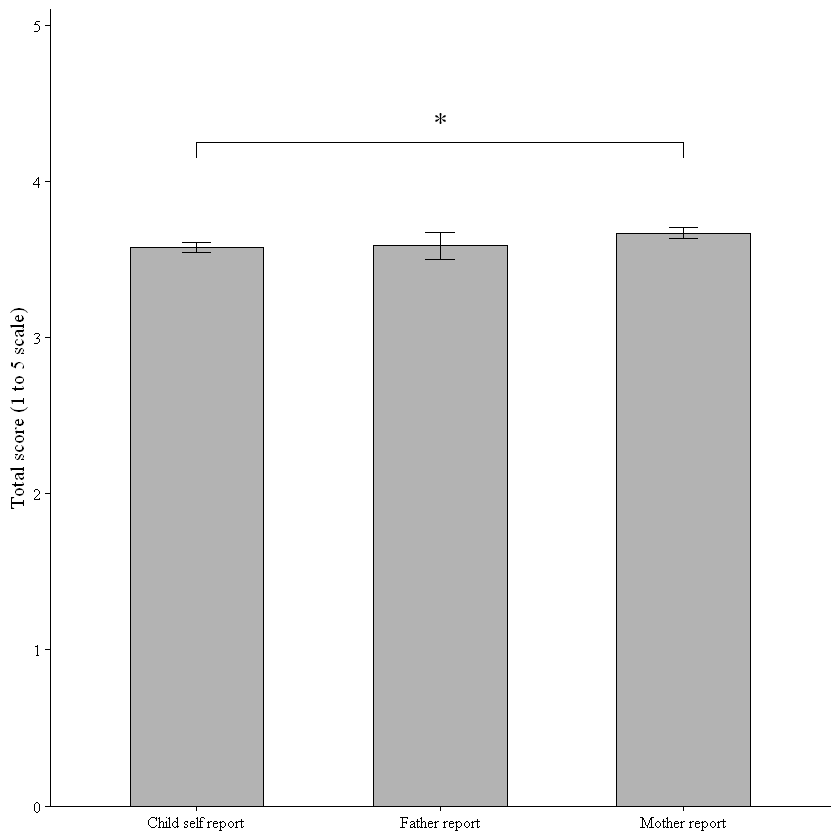

In [10]:
# §7 - Figure 1 (manuscript): column plot with SE bars. Child self report is one fixed column
# (all dyad children); caregiver reports split into mothers and fathers.
fig_dat <- bind_rows(
  df_dy |> transmute(grupo = "Child self report", score = total_aluno),
  df_dy |> filter(resp == "Male") |> transmute(grupo = "Father report", score = total_familia),
  df_dy |> filter(resp == "Female") |> transmute(grupo = "Mother report", score = total_familia)) |>
  mutate(grupo = factor(grupo, levels = c("Child self report", "Father report", "Mother report"))) |>
  summarise(m = mean(score), se = sd(score) / sqrt(n()), n = n(), .by = grupo)
print(fig_dat)

ggplot(fig_dat, aes(grupo, m)) +
  geom_col(fill = "grey70", color = "black", width = .55) +
  geom_errorbar(aes(ymin = m - se, ymax = m + se), width = .12, color = "black") +
  annotate("segment", x = 1, xend = 3, y = 4.25, yend = 4.25, color = "black") +
  annotate("segment", x = 1, xend = 1, y = 4.25, yend = 4.15, color = "black") +
  annotate("segment", x = 3, xend = 3, y = 4.25, yend = 4.15, color = "black") +
  annotate("text", x = 2, y = 4.38, label = "*", size = 6) +
  scale_y_continuous(limits = c(0, 5), breaks = 0:5, expand = expansion(mult = c(0, 0.02))) +
  labs(x = NULL, y = "Total score (1 to 5 scale)") +
  theme_classic(base_size = 12, base_family = "serif")

### §8. Measurement invariance

Checks that the two factor model carries the same meaning across sex and across informants before scores are compared.

In [11]:
# §8 - measurement invariance (criterion: reject a step if ΔCFI < -.01; Cheung & Rensvold, 2002)
# Models. (a) across sex, full student sample (girls x boys): m2 from §2, configural vs thresholds+loadings.
# (b) across informants in the dyads, graded sequence (Putnick & Bornstein, 2016):
# configural -> metric (equal loadings of matching items) -> scalar (adds equal thresholds)
# lab(pre, ix): indicators of one factor with loading labels shared across informants
lab <- \(pre, ix) paste(sprintf("l%d*%s%d", ix, pre, ix), collapse = " + ")
m_cfg <- "engA =~ a1+a3+a5+a7+a9
regA =~ a2+a4+a6+a8+a10+a11
engP =~ p1+p3+p5+p7+p9
regP =~ p2+p4+p6+p8+p10+p11"
m_metric <- paste(sprintf("engA =~ %s", lab("a", f1)), sprintf("regA =~ %s", lab("a", f2)),
                  sprintf("engP =~ %s", lab("p", f1)), sprintf("regP =~ %s", lab("p", f2)), sep = "\n")
m_scalar <- paste(m_metric,
                  paste(unlist(map(1:11, \(i) map(1:4, \(t) sprintf("a%d | th%d_%d*t%d\np%d | th%d_%d*t%d",
                                                                    i, i, t, t, i, i, t, t)))), collapse = "\n"),
                  sep = "\n")

In [12]:
# Run: sex groups in the full student sample (girls x boys); informant models in the dyads
fit_cfg <- cfa(m2, filter(df_st, demographics.gender %in% c("Feminino", "Masculino")),
               ordered = TRUE, estimator = "WLSMV", group = "demographics.gender")
fit_con <- cfa(m2, filter(df_st, demographics.gender %in% c("Feminino", "Masculino")),
               ordered = TRUE, estimator = "WLSMV", group = "demographics.gender",
               group.equal = c("thresholds", "loadings"))
fit0 <- cfa(m_cfg, df_dy, ordered = TRUE, estimator = "WLSMV")
fit_m <- cfa(m_metric, df_dy, ordered = TRUE, estimator = "WLSMV")
fit_s <- cfa(m_scalar, df_dy, ordered = TRUE, estimator = "WLSMV")

In [13]:
# Summary: CFI per step, scaled difference tests and latent cross informant correlations
cat(sprintf("Sex - configural: CFI = %.3f | thresholds+loadings: CFI = %.3f (held)\n",
    fitMeasures(fit_cfg, "cfi.scaled"), fitMeasures(fit_con, "cfi.scaled")))
print(lavTestLRT(fit_cfg, fit_con))
cat(sprintf("Informants - configural CFI = %.3f | metric CFI = %.3f (held) | scalar CFI = %.3f (rejected)\n",
    fitMeasures(fit0, "cfi.scaled"), fitMeasures(fit_m, "cfi.scaled"), fitMeasures(fit_s, "cfi.scaled")))
print(lavTestLRT(fit0, fit_m))
print(lavTestLRT(fit_m, fit_s))
cat("latent cross informant correlations (configural):\n")
print(round(lavInspect(fit0, "cor.lv")[1:2, 3:4], 2))

Sex - configural: CFI = 0.928 | thresholds+loadings: CFI = 0.936 (held)



Scaled Chi-Squared Difference Test (method = "satorra.2000")

lavaan->lavTestLRT():  
   lavaan NOTE: The "Chisq" column contains standard test statistics, not the 
   robust test that should be reported per model. A robust difference test is 
   a function of two standard (not robust) statistics.

         Df AIC BIC  Chisq Chisq diff RMSEA Df diff Pr(>Chisq)
fit_cfg  86         164.24                                    
fit_con 117         178.86     23.552     0      31     0.8284


Informants - configural CFI = 0.942 | metric CFI = 0.948 (held) | scalar CFI = 0.843 (rejected)



Scaled Chi-Squared Difference Test (method = "satorra.2000")

lavaan->lavTestLRT():  
   lavaan NOTE: The "Chisq" column contains standard test statistics, not the 
   robust test that should be reported per model. A robust difference test is 
   a function of two standard (not robust) statistics.

       Df AIC BIC  Chisq Chisq diff    RMSEA Df diff Pr(>Chisq)
fit0  203         359.07                                       
fit_m 212         372.78     7.2618 0.035887       9     0.6099



Scaled Chi-Squared Difference Test (method = "satorra.2000")

lavaan->lavTestLRT():  
   lavaan NOTE: The "Chisq" column contains standard test statistics, not the 
   robust test that should be reported per model. A robust difference test is 
   a function of two standard (not robust) statistics.

       Df AIC BIC  Chisq Chisq diff   RMSEA Df diff Pr(>Chisq)    
fit_m 212         372.78                                          
fit_s 256         863.78     403.94 0.15818      44  < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


latent cross informant correlations (configural):


     engP regP
engA 0.47 0.24
regA 0.19 0.30
